In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [3]:
X.isna().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [4]:
X

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [6]:
# Find the most frequent value (index 0 is the top result)
mode_value = X['workclass'].mode()[0]
mode_value

'Private'

In [7]:
X['workclass'] = X['workclass'].fillna("Unknown")

C:\Users\M M\AppData\Local\Temp\ipykernel_1648\836367453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['workclass'] = X['workclass'].fillna("Unknown")


In [8]:
X.isna().sum()

age                 0
workclass           0
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [9]:
# k nn is impitor
from sklearn.impute import KNNImputer
import pandas, numpy
from sklearn.impute import KNNImputer

In [10]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

data = pd.DataFrame({'Age' : [25,30,np.nan,
                              0,35,np.nan,28],'Salary' : [5000,60000,55000,np.nan,65000,52000,np.nan],'Expreience': [2,5,3,10,7,4,3]})
print(data)

    Age   Salary  Expreience
0  25.0   5000.0           2
1  30.0  60000.0           5
2   NaN  55000.0           3
3   0.0      NaN          10
4  35.0  65000.0           7
5   NaN  52000.0           4
6  28.0      NaN           3


In [11]:
#apply knn
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(data)
imputed_data = pd.DataFrame(imputed_array,columns=data.columns)
print("\n DATA after KNN Imputation\n")
print(imputed_data)


 DATA after KNN Imputation

    Age   Salary  Expreience
0  25.0   5000.0         2.0
1  30.0  60000.0         5.0
2  23.6  55000.0         3.0
3   0.0  47400.0        10.0
4  35.0  65000.0         7.0
5  23.6  52000.0         4.0
6  28.0  47400.0         3.0


In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
#Dateset
data = np.array([10,50,55,57,70,75,76,78,80,100,120])

In [14]:
#calculate Q1 Q3 and IQR
Q1 = np.percentile(data,25)
Q2 = np.percentile(data,50)
Q3 = np.percentile(data,75)
print("Q1:",Q1)
print("Q2:",Q2)
print("Q3:",Q3)

#IQR = Q3 - Q1
IQR = Q3 - Q1
print("IQR:",IQR)

#Calculate lower and upper bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:",lower_bound)
print("Upper Bound:",upper_bound)


Q1: 56.0
Q2: 75.0
Q3: 79.0
IQR: 23.0
Lower Bound: 21.5
Upper Bound: 113.5


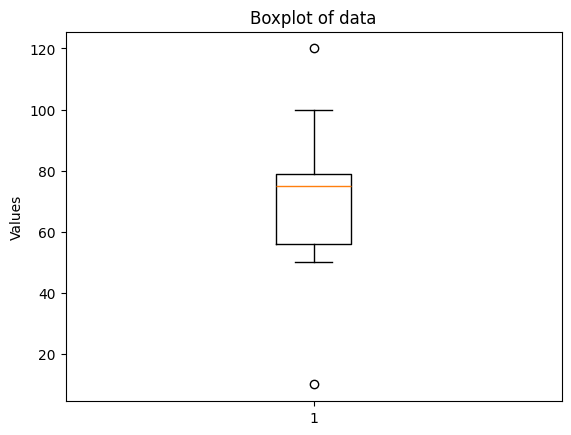

In [15]:
#1. Boxplot
plt.figure()
plt.boxplot(data)
plt.title("Boxplot of data")
plt.ylabel("Values")
plt.show()

In [16]:
import pandas as pd

#Create a sample dataset
data = {
    'Customer': ['Riya','Meena','Tejes','Divya','Paras'],
    'Satisfaction': ['Low','High','Medium','High','Low']
}

df = pd.DataFrame(data)
print(df)

  Customer Satisfaction
0     Riya          Low
1    Meena         High
2    Tejes       Medium
3    Divya         High
4    Paras          Low


In [17]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['LabelEncoder'] = label.fit_transform(df['Satisfaction'])
print(df)

  Customer Satisfaction  LabelEncoder
0     Riya          Low             1
1    Meena         High             0
2    Tejes       Medium             2
3    Divya         High             0
4    Paras          Low             1


In [18]:
from sklearn.preprocessing import OrdinalEncoder
#Define correct order
rank = [['Low','Medium','High','Vary High']]
order = OrdinalEncoder(categories=rank)
df['OrdinalEncoder'] = order.fit_transform(df[['Satisfaction']]).astype(int)
print(df)

  Customer Satisfaction  LabelEncoder  OrdinalEncoder
0     Riya          Low             1               0
1    Meena         High             0               2
2    Tejes       Medium             2               1
3    Divya         High             0               2
4    Paras          Low             1               0


In [19]:
#one_hot = pd.get_dummies(df['Satisfaction'], prefix='Satisfaction')
#one_hot
X=df["Satisfaction"]
user_encoder = pd.get_dummies(X).astype(int)
user_encoder

,High,Low,Medium
0,0,1,0
1,1,0,0
2,0,0,1
3,1,0,0
4,0,1,0


In [20]:
import pandas as pd
data = {
    'salary' : [30000,50000,70000,200000],
    'exparience' : [2,5,7,10],
    'age': [25,30,35,60]
}
df = pd.DataFrame(data)
print(df)

   salary  exparience  age
0   30000           2   25
1   50000           5   30
2   70000           7   35
3  200000          10   60


In [21]:
min_salary = df['salary'].min()
max_salary = df['salary'].max()

print(f"Minimum Salary: {min_salary}")
print(f"Maximum Salary: {max_salary}")

Minimum Salary: 30000
Maximum Salary: 200000


In [22]:
from sklearn.preprocessing import MaxAbsScaler
maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(maxabs_scaler.fit_transform(df), columns=df.columns)
print(df_maxabs)

   salary  exparience       age
0    0.15         0.2  0.416667
1    0.25         0.5  0.500000
2    0.35         0.7  0.583333
3    1.00         1.0  1.000000


In [23]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(df), columns=df.columns)
print(df_minmax)

     salary  exparience       age
0  0.000000       0.000  0.000000
1  0.117647       0.375  0.142857
2  0.235294       0.625  0.285714
3  1.000000       1.000  1.000000


In [24]:
#L2 normalization(default)
from sklearn.preprocessing import Normalizer
l2_normalizer = Normalizer(norm='l2')
df_l2 = pd.DataFrame(l2_normalizer.fit_transform(df), columns=df.columns)
print("\n L2 Normalized Data\n")
print(df_l2)



 L2 Normalized Data

   salary  exparience       age
0     1.0    0.000067  0.000833
1     1.0    0.000100  0.000600
2     1.0    0.000100  0.000500
3     1.0    0.000050  0.000300


In [25]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(standard_scaler.fit_transform(df), columns=df.columns)
print(df_standard)

     salary  exparience       age
0 -0.865004   -1.371989 -0.928477
1 -0.564133   -0.342997 -0.557086
2 -0.263262    0.342997 -0.185695
3  1.692399    1.371989  1.671258


* # HW :- Preprosessing or feature engineering

1. Find dataset from UCIML that having numerical and string missing values and handle it with KNNimputer
2. Find dataset from UCIML that having outlier find method to find outlier from dataset rather than IQR